In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

import sys
sys.path.append('..')
sys.path.insert(0, '../maldi_PIKE/maldi-learn/maldi_learn/')
sys.path.insert(0, '../Kernel/')

import warnings
warnings.filterwarnings('ignore')
import pickle

In [2]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
import seaborn as sns
palette = 'Set2'
sns.set_style('ticks')
sns.set_context('paper')
sns.set_palette(palette)
plt.rcParams['font.family'] = 'serif'

# Load and preprocess dataset

In [4]:
# Load data
mq_data = pd.read_csv('../../MALDI data/mq_data_zeros.csv', index_col='NUMERO')

# Labels
labels = pd.read_csv('../../MALDI data/cleaned_labels.csv')

# Labels
labels_df = labels.merge(mq_data, how='inner', left_on='NUMERO', right_on=mq_data.index)[labels.columns]
labels_df = labels_df[labels_df['AÑO'] < 2020]
labels_df['F REGISTRO'] = pd.to_datetime(labels_df['F REGISTRO'])
labels_df = labels_df.sort_values(by='F REGISTRO')
labels_df.index = labels_df.NUMERO

mq_data = mq_data.loc[mq_data.index.isin(labels_df.index)]

In [5]:
with open('../../MALDI data/complete_kernels.pkl', 'rb') as f:
    complete_kernel_dict = pickle.load(f)

with open('../../MALDI data/masked_kernels.pkl', 'rb') as f:
    masked_kernel_dict = pickle.load(f)

with open('../../MALDI data/peaks_kernels.pkl', 'rb') as f:
    peaks_kernel_dict = pickle.load(f)

with open('../../MALDI data/K_X_XR_kernels.pkl', 'rb') as f:
    K_X_XR_kernel_dict = pickle.load(f)

with open('../../MALDI data/K_XR_XR_kernels.pkl', 'rb') as f:
    K_XR_XR_kernel_dict = pickle.load(f)

with open('../../MALDI data/mock_MALDI.pkl', 'rb') as f:
    mock_MALDI = pickle.load(f)

with open('../../MALDI data/complete_prepared.pkl', 'rb') as f:
    complete_prepared_dict = pickle.load(f)

with open('../../MALDI data/binned_complete.pkl', 'rb') as f:
    binned_ciomplete_dict = pickle.load(f)

with open('../../MALDI data/binned_masled.pkl', 'rb') as f:
    binned_masked_dict = pickle.load(f)

with open('../../MALDI data/peaks_info_dict.pkl', 'rb') as f:
    peaks_clusters_info_dict = pickle.load(f)

with open('../../MALDI data/complete_info_dict.pkl', 'rb') as f:
    complete_clusters_info_dict = pickle.load(f)

peaks_list = pd.read_excel('../../MALDI data/Proteinas ribosomales E. coli.xlsx', usecols='D', nrows=46).to_numpy()[1:]
peaks_list = peaks_list.astype(int).flatten()

## Analysis

In [6]:
def find_common_samples(file_names, n_clusters):
    set_dict = {n: [] for n in range(n_clusters)}

    for cluster in range(n_clusters):
        for file_name in file_names:
            df = pd.read_csv(file_name)
            set_dict[cluster].append(set(df[f'Cluster {cluster}'].dropna().astype(int)))

    cluster_intersect = {cluster: set.intersection(*set_dict[cluster]) for cluster in range(n_clusters)}
    cluster_union = {cluster: set.union(*set_dict[cluster]) for cluster in range(n_clusters)}
    non_intersecting_ids = {cluster: cluster_union[cluster] - cluster_intersect[cluster] for cluster in range(n_clusters)}
    non_intersecting_ids = set.union(*non_intersecting_ids.values())

    return cluster_intersect, non_intersecting_ids

In [7]:
folder_path = './clusters/noSPR'
file_names = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

cluster_intersect_noSPR, non_intersecting_ids_noSPR = find_common_samples(file_names, 3)

for cluster, ids_int in enumerate(cluster_intersect_noSPR.values()):
    print(f"Cluster {cluster} consistent IDs: {len(ids_int)}")

print(f"Non consistent IDs: {len(non_intersecting_ids_noSPR)}")

Cluster 0 consistent IDs: 816
Cluster 1 consistent IDs: 356
Cluster 2 consistent IDs: 243
Non consistent IDs: 110


In [8]:
folder_path = './clusters/masked'
file_names = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

cluster_intersect_masked, non_intersecting_ids_masked = find_common_samples(file_names, 3)

for cluster, ids_int in enumerate(cluster_intersect_masked.values()):
    print(f"Cluster {cluster} consistent IDs: {len(ids_int)}")

print(f"Non consistent IDs: {len(non_intersecting_ids_masked)}")

Cluster 0 consistent IDs: 511
Cluster 1 consistent IDs: 143
Cluster 2 consistent IDs: 253
Non consistent IDs: 618


In [9]:
folder_path = './clusters/SPR'
file_names = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]

cluster_intersect_SPR, non_intersecting_ids_SPR = find_common_samples(file_names, 3)

for cluster, ids_int in enumerate(cluster_intersect_SPR.values()):
    print(f"Cluster {cluster} consistent IDs: {len(ids_int)}")

print(f"Non consistent IDs: {len(non_intersecting_ids_SPR)}")

Cluster 0 consistent IDs: 701
Cluster 1 consistent IDs: 415
Cluster 2 consistent IDs: 241
Non consistent IDs: 168


In [10]:
folder_paths = './clusters/SPR'
folder_path_2 = './clusters/noSPR'
folder_path_3 = './clusters/masked'
file_names = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv') and 'logbins' not in file]
file_names += [os.path.join(folder_path_2, file) for file in os.listdir(folder_path_2) if file.endswith('.csv') and 'logbins' not in file]
file_names += [os.path.join(folder_path_3, file) for file in os.listdir(folder_path_3) if file.endswith('.csv') and 'logbins' not in file]
print(file_names)

cluster_intersect_both, non_intersecting_ids_both = find_common_samples(file_names, 3)

for cluster, ids_int in enumerate(cluster_intersect_both.values()):
    print(f"Cluster {cluster} consistent IDs: {len(ids_int)}")

print(f"Non consistent IDs: {len(non_intersecting_ids_both)}")

['./clusters/SPR\\samples_per_cluster_ctbins_SPR.csv', './clusters/noSPR\\samples_per_cluster_ctbins_noSPR.csv', './clusters/masked\\samples_per_cluster_ctbins_masked.csv']
Cluster 0 consistent IDs: 233
Cluster 1 consistent IDs: 1
Cluster 2 consistent IDs: 232
Non consistent IDs: 1059


## Mean MALDIs

In [11]:
mz_range = np.arange(2000, 20000)
bin_size = 3
num_bins = len(mz_range) // bin_size

histogram_heights = np.zeros(num_bins)
bin_indices = (peaks_list - 2000) // bin_size
for idx in bin_indices:
    histogram_heights[max(0, idx - 10):min(num_bins, idx + 11)] = 0.6

In [12]:
def plot_mean_maldi(intersection_dict, common_bins_dict = {}, fig_name='mean_MALDI_common_ids_noSPR'):

    fig, axes = plt.subplots(len(intersection_dict.keys()), 1, figsize=(15, 10), layout='tight', sharex=True)
    colors = ['red', 'blue', 'green', 'orange']

    labels = complete_clusters_info_dict['Ct. bins'].index
    value_data = complete_prepared_dict['Ct. bins'][:,:,1] / np.max(complete_prepared_dict['Ct. bins'][:,:,1])
    value_df = pd.DataFrame(value_data)
    value_df['NUMERO'] = labels
    value_df.set_index('NUMERO', inplace=True)

    # Common bins
    num_bins = 6000
    histogram_heights_common_dict = {key: np.zeros(num_bins) for key in intersection_dict.keys()}
    for key, indices in common_bins_dict.items():
        for idx in indices:
            histogram_heights_common_dict[key][max(0, idx - 10):min(num_bins, idx + 11)] = 0.6

    for i in range(len(intersection_dict.keys())):
        cluster_data = value_df.loc[intersection_dict[i]]
        cluster_means = cluster_data.mean().drop(columns='NUMERO', errors='ignore')
        cluster_std = cluster_data.std().drop(columns='NUMERO', errors='ignore')
        cluster_means_plus_std = cluster_means + 1 * cluster_std
        label = 'Non Intersecting Samples' if i == len(intersection_dict.keys()) and len(intersection_dict.keys()) > 3 else f'Cluster {i}'
        
        axes[i].plot(cluster_means.to_numpy(), label="Mean value", linewidth=1.5, color=colors[i])
        axes[i].plot(cluster_means_plus_std.to_numpy(), label=f'1 std', linewidth=1.5, color='gray', linestyle='dotted')

        axes[i].bar(range(num_bins), histogram_heights, width=1.0, alpha=0.3, edgecolor='none', color='skyblue')
        axes[i].bar(range(num_bins), histogram_heights_common_dict[i], width=1.0, alpha=0.7, edgecolor='none', color='moccasin')
        axes[i].set_title(label, fontsize=13)
        axes[i].set_xticks(np.arange(-100, 3100, 100))
        axes[i].set_ylabel(f"Mean Bin Intenity")
        axes[i].set_xlim(-100, 3000)
        axes[i].legend()
        axes[i].grid()
        axes[-1].set_xlabel(f"Bins")

    plt.savefig(f'c:/Users/rafar/Desktop/UC3M/2nd Semester/6 Master Thesis/Images/{fig_name}.png', dpi=500) 
    plt.show()

In [13]:
cluster_intersect_noSPR[3] = non_intersecting_ids_noSPR
common_bins_dict = {0: [470, 480, 490]}


plot_mean_maldi(cluster_intersect_noSPR, common_bins_dict, fig_name='mean_MALDI_common_ids_noSPR')

KeyboardInterrupt: 

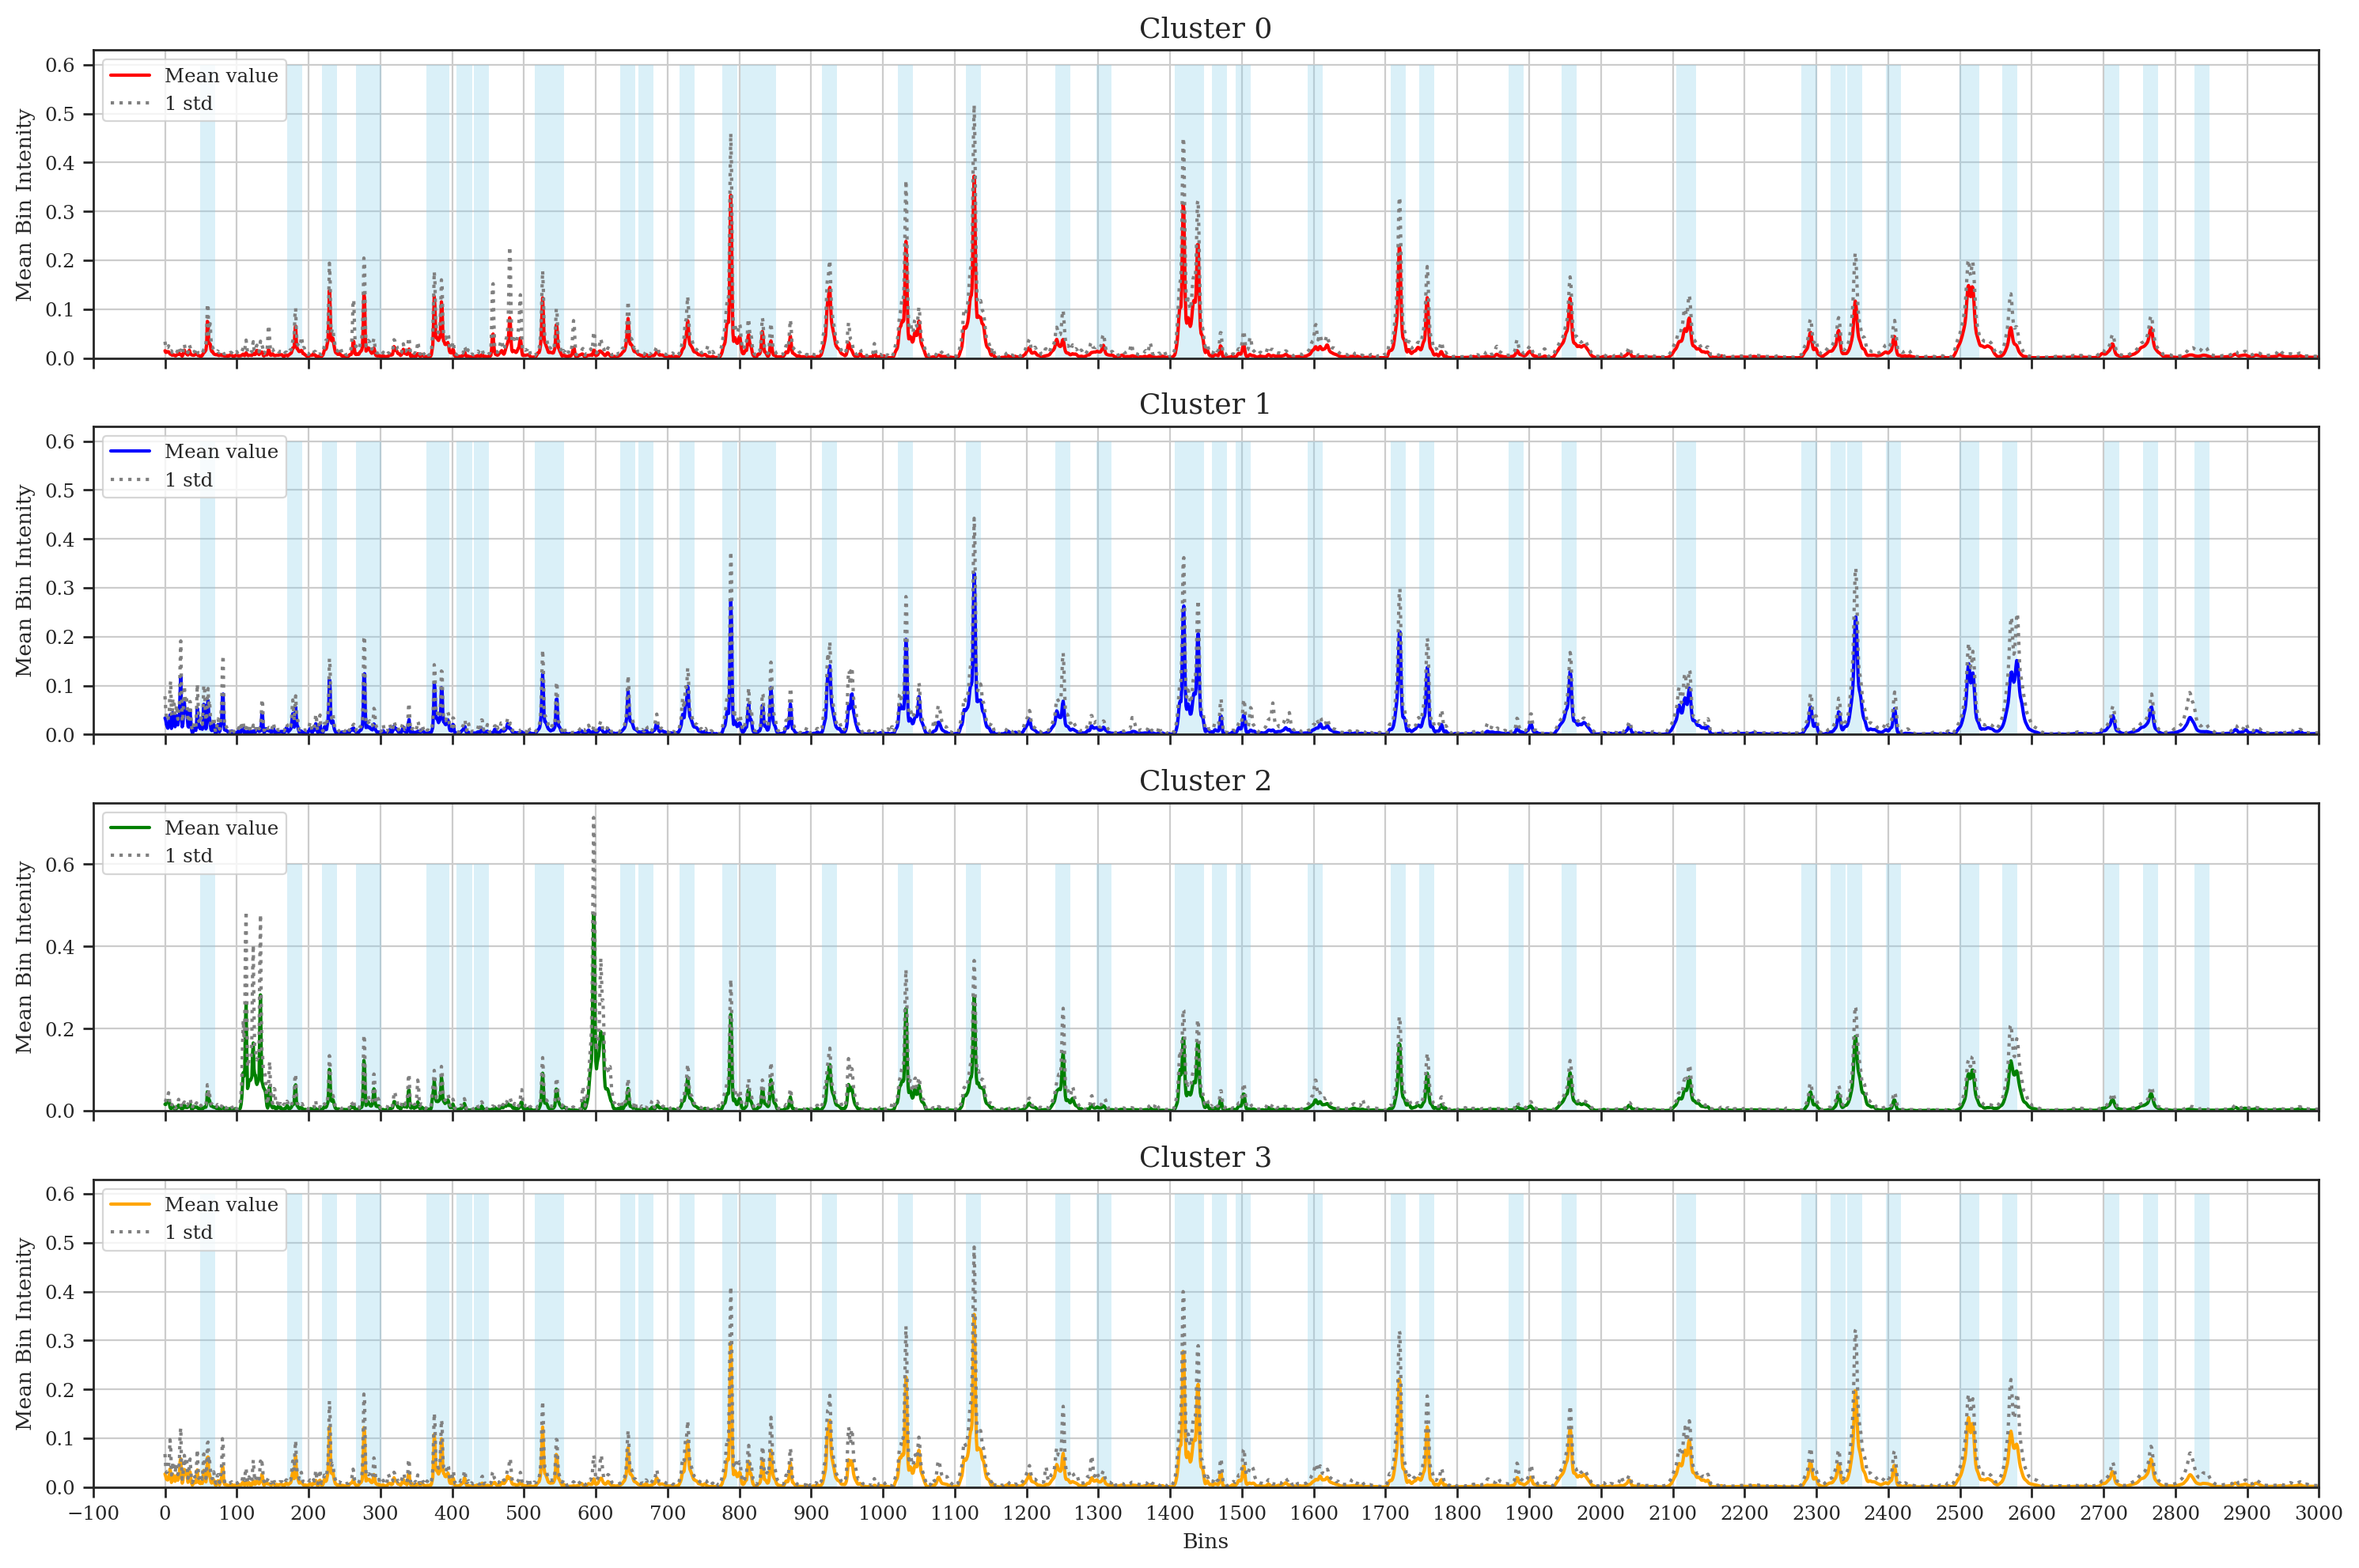

In [ ]:
cluster_intersect_masked[3] = non_intersecting_ids_masked
plot_mean_maldi(cluster_intersect_masked, fig_name='mean_MALDI_common_ids_masked')

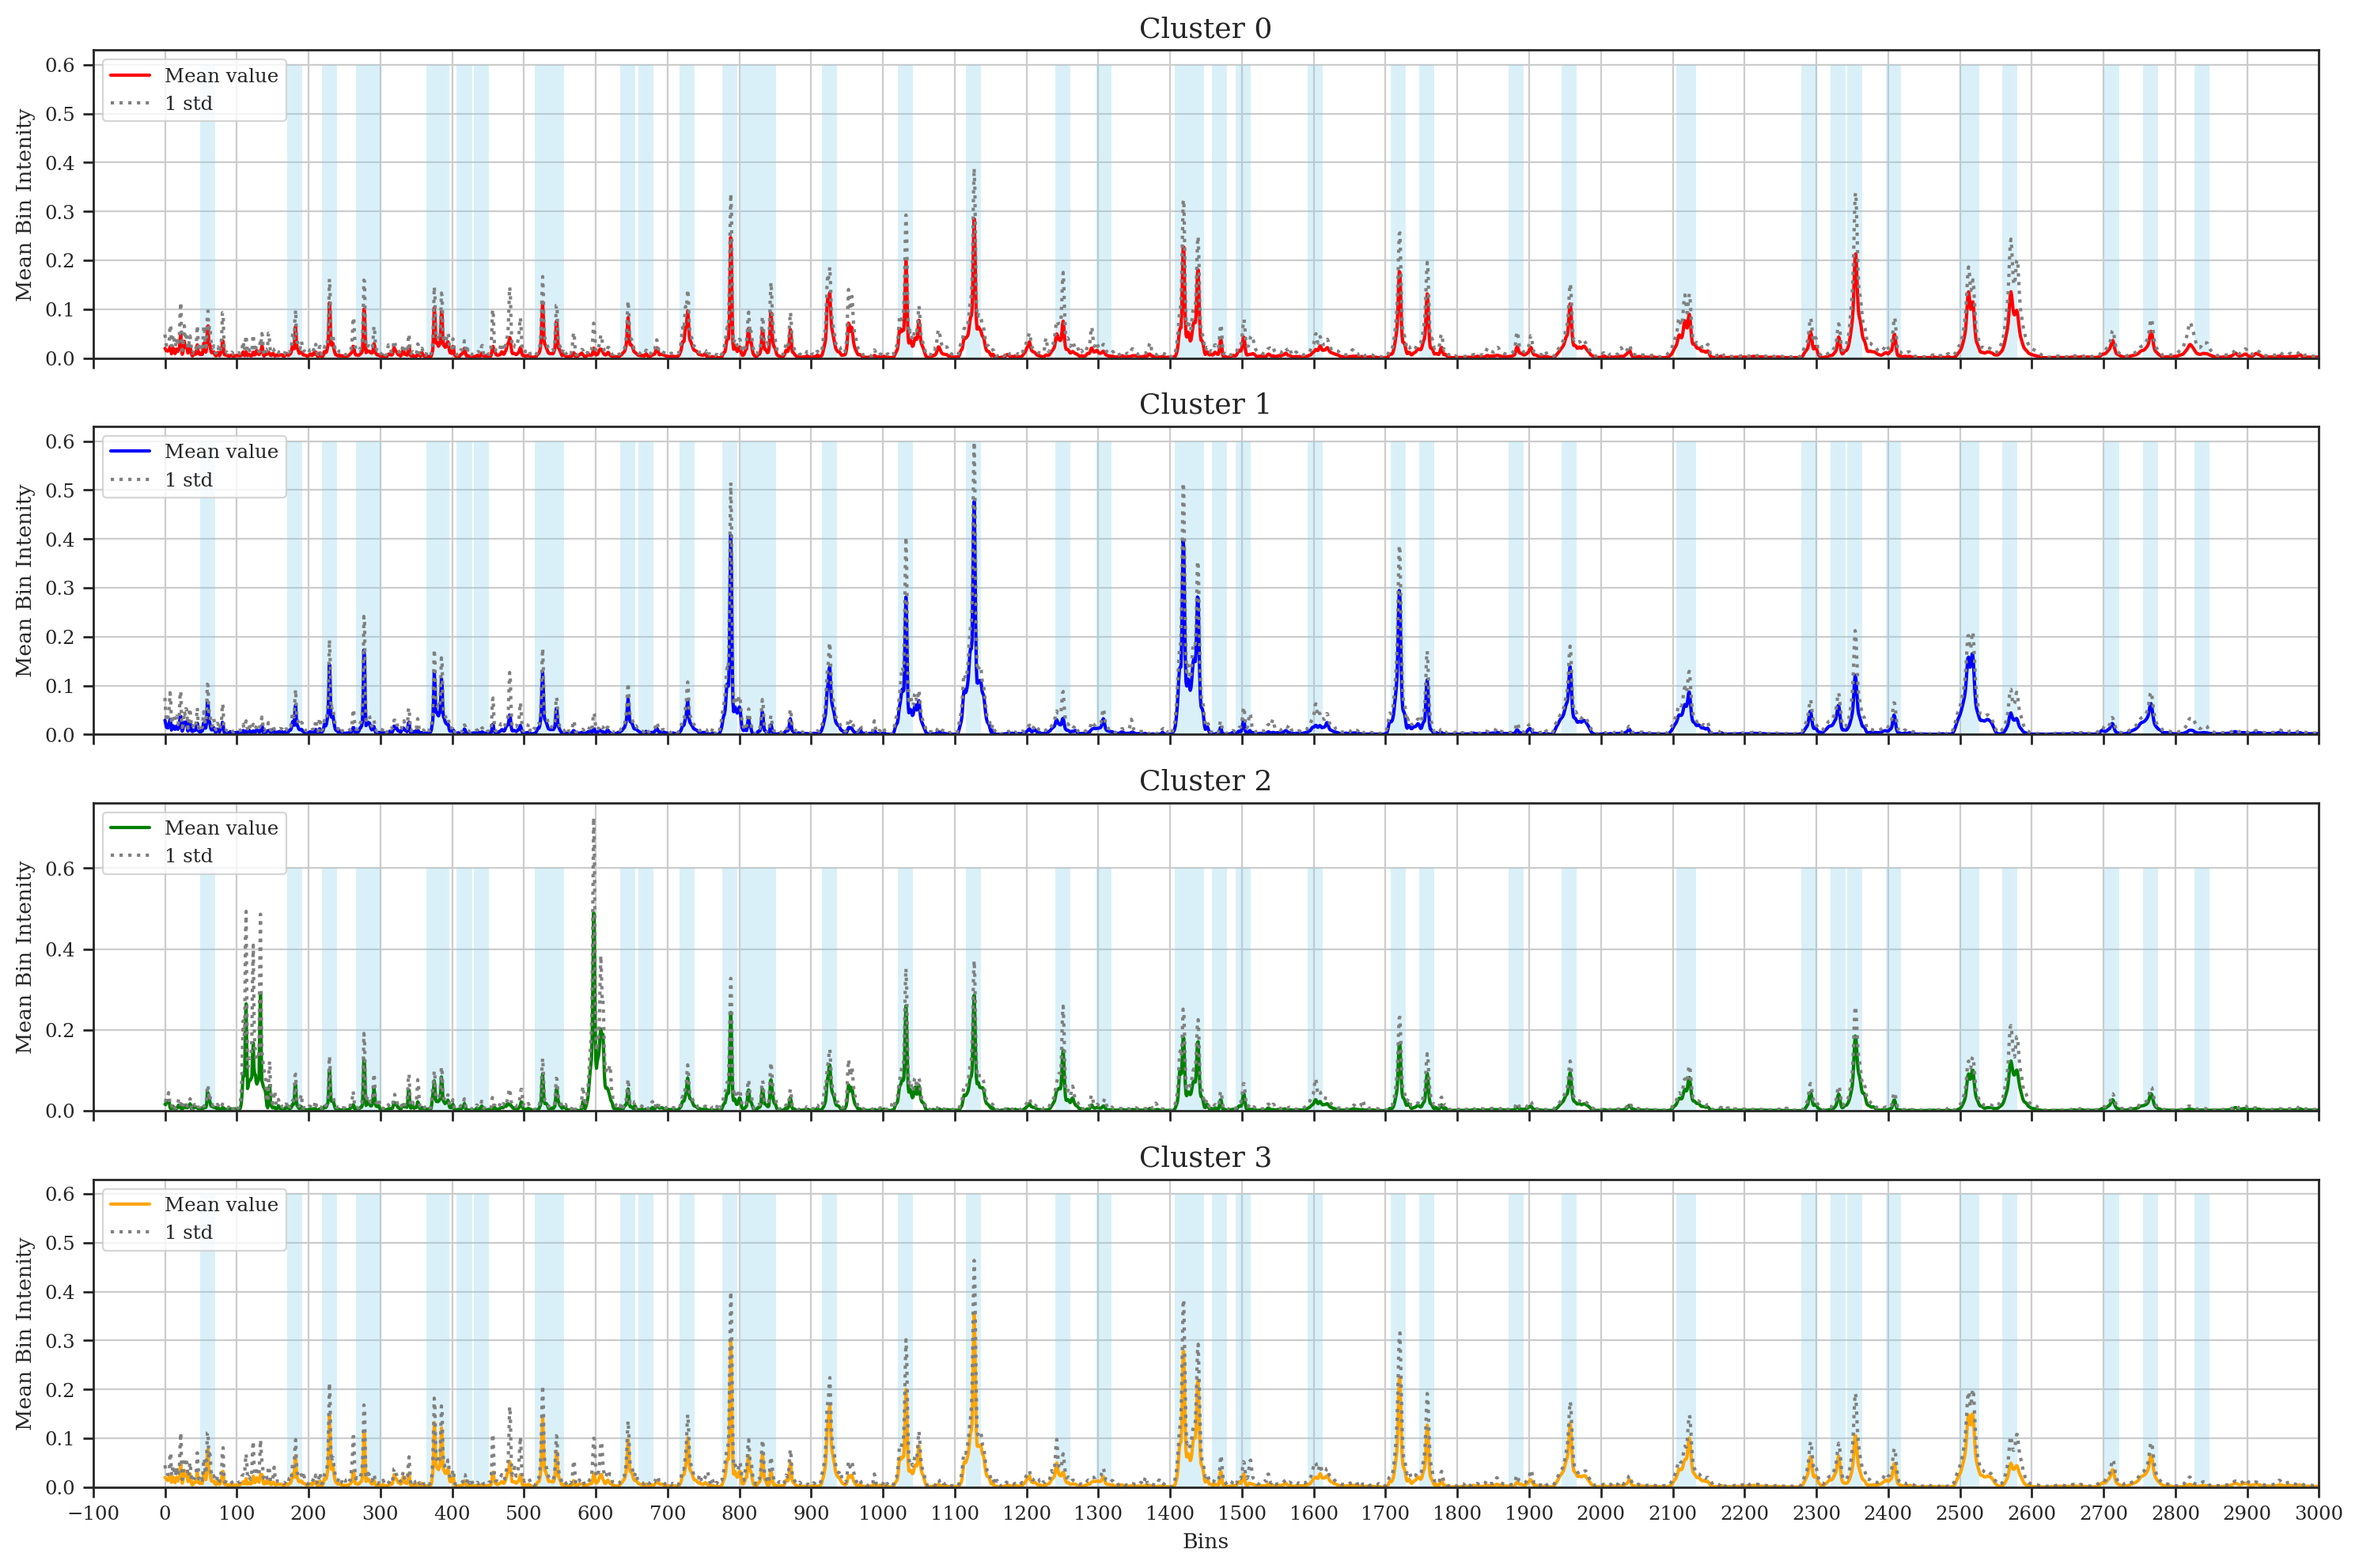

In [ ]:
cluster_intersect_SPR[3] = non_intersecting_ids_SPR
plot_mean_maldi(cluster_intersect_SPR, fig_name='mean_MALDI_common_ids_SPR')

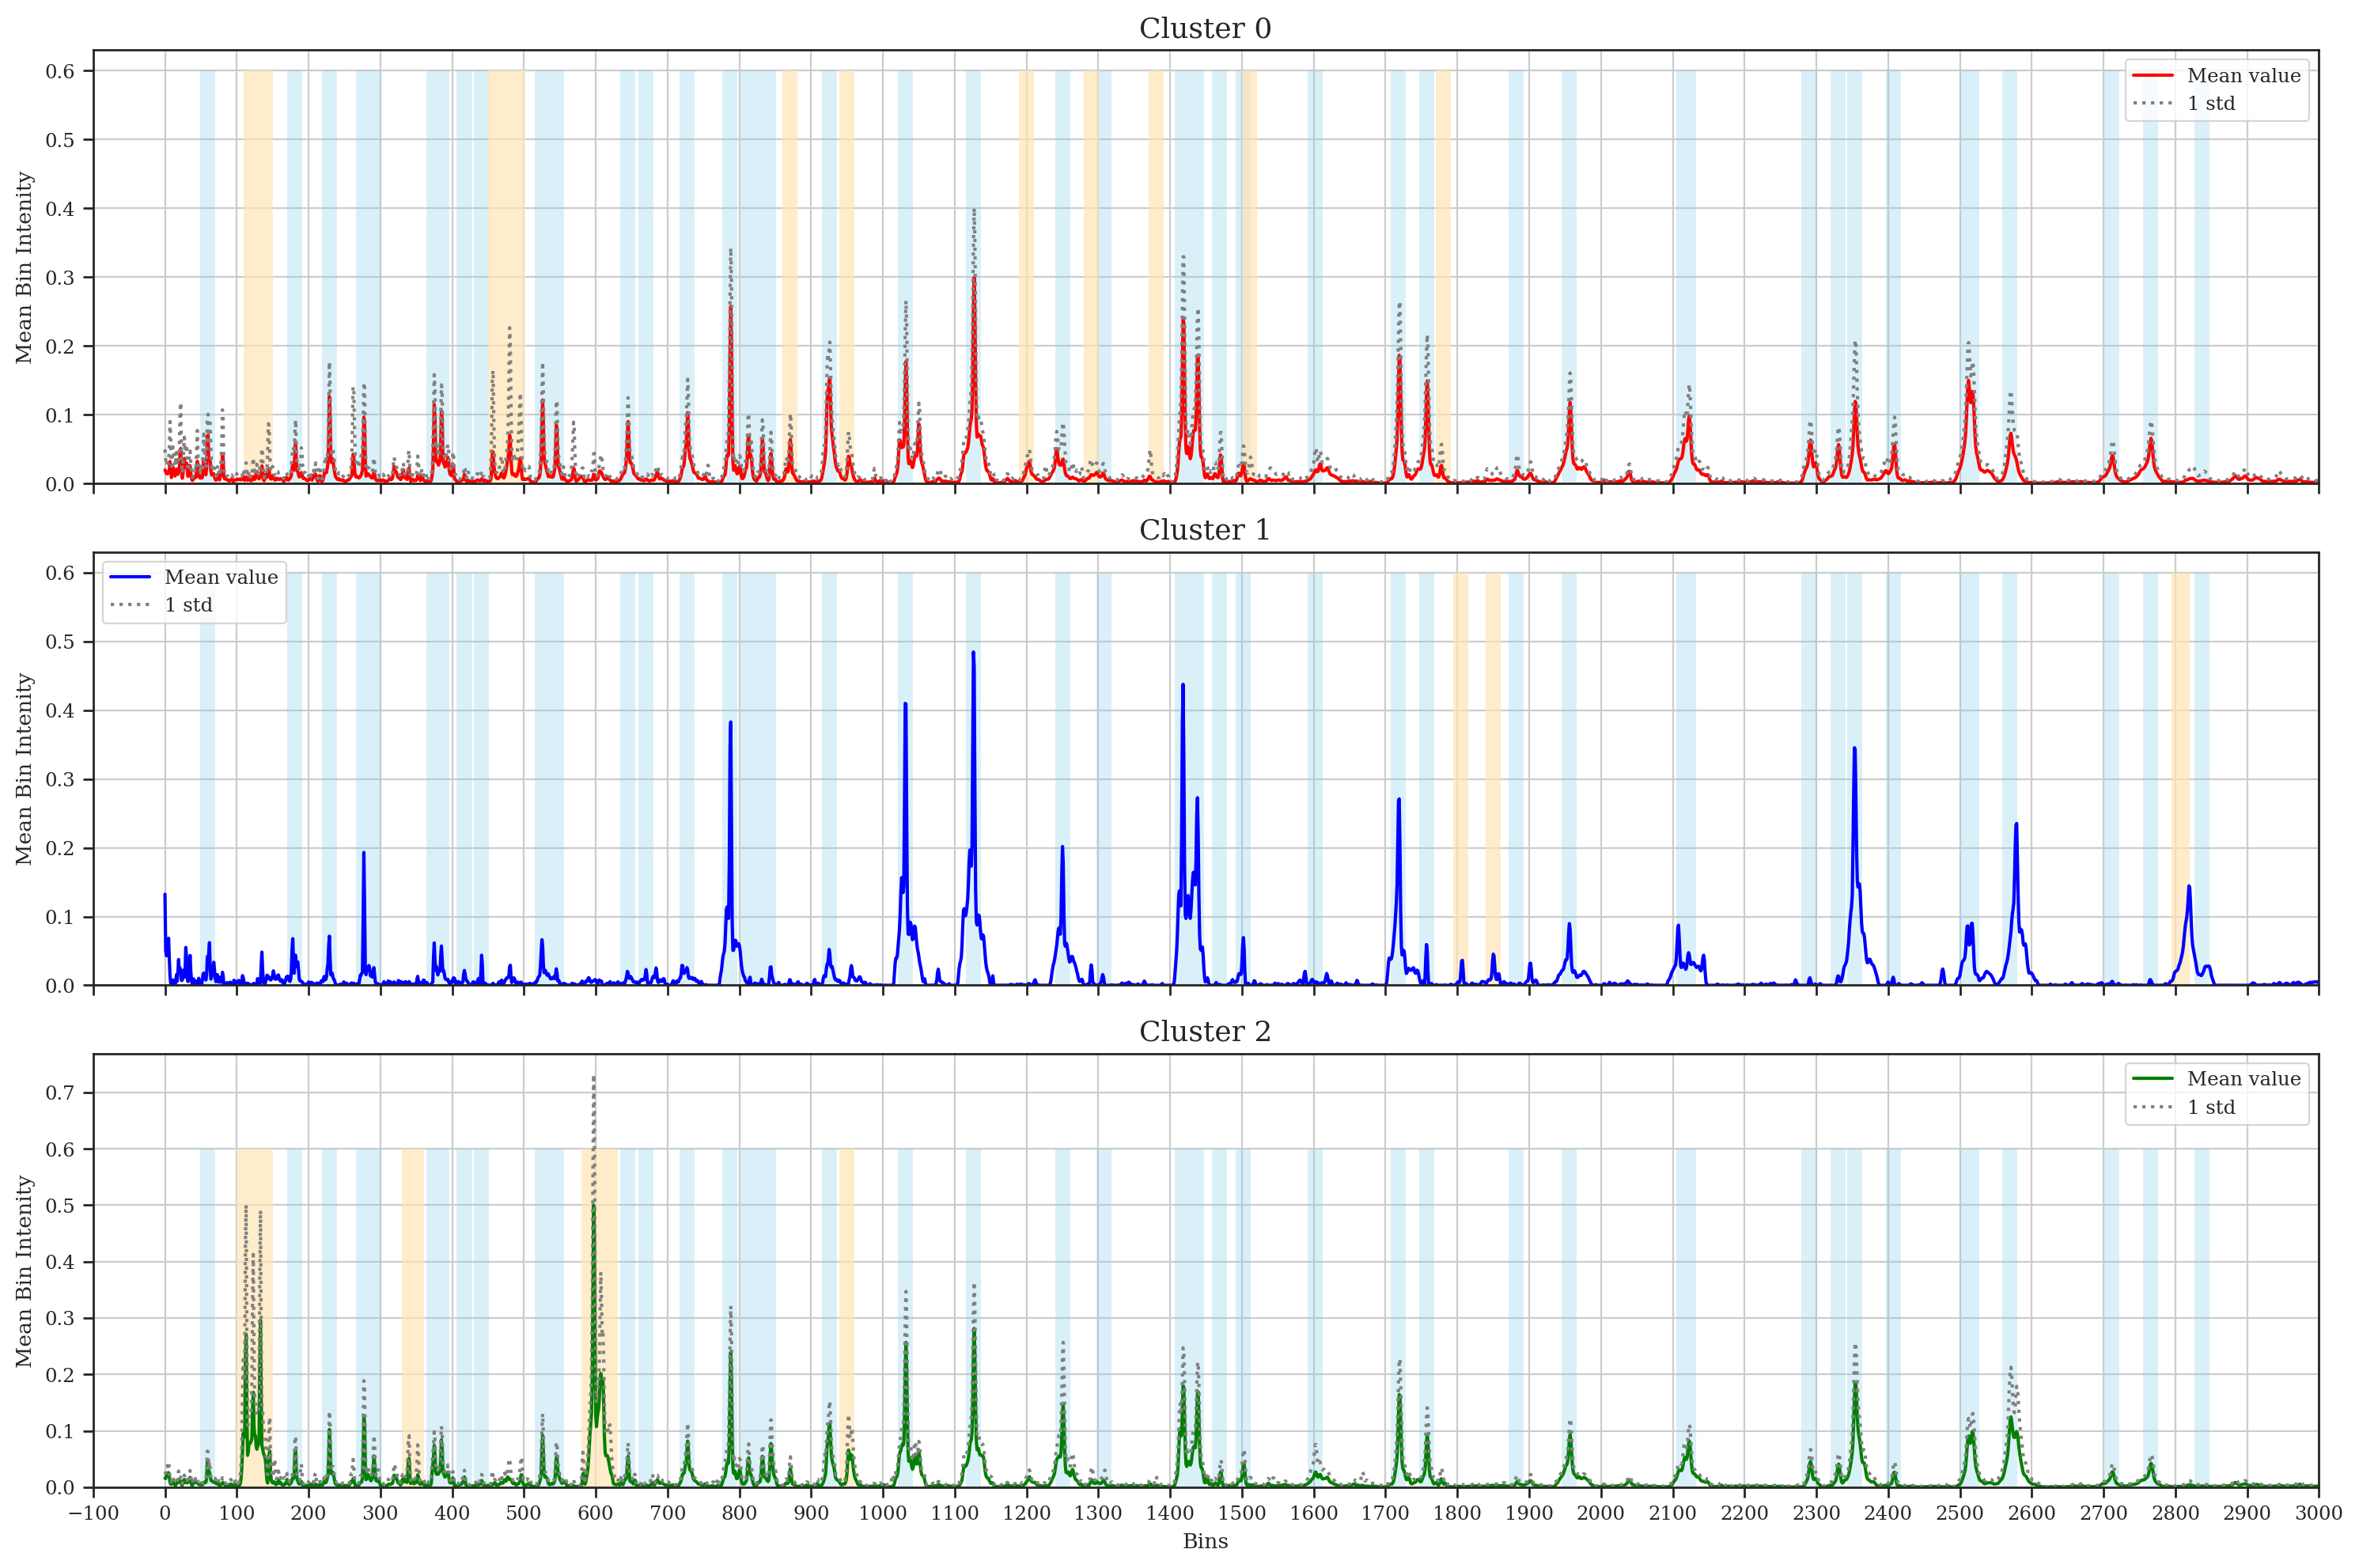

In [14]:
# cluster_intersect_both[3] = non_intersecting_ids_both
common_bins_dict = {0: [120, 130, 140, 460, 470, 480, 490, 870, 950, 1200, 1290, 1380, 1510, 1780],
                    1: [1805, 1850, 2805, 2810],
                    2: [110, 120, 130, 140, 340, 350, 590, 600, 610, 620, 950]
                }

plot_mean_maldi(cluster_intersect_both, common_bins_dict=common_bins_dict, fig_name='mean_MALDI_common_ids_both')

## Samples that are not common

In [ ]:
def analyze_samples(ids, df):
    # Filter the DataFrame to only include rows with IDs in the given set
    filtered_df = df[df['NUMERO'].isin(ids)]

    # Calculate the proportion of Resistencia (1) vs (0)
    resistencia_counts = filtered_df['RESISTENCIA'].value_counts(normalize=True)
    resistencia_proportion = resistencia_counts.to_dict()

    # Calculate the proportion of each TIPO ECOLI
    tipo_ecoli_counts = filtered_df['TIPO ECOLI'].value_counts(normalize=True)
    tipo_ecoli_proportion = tipo_ecoli_counts.to_dict()

    # Find the 3 most common SERVICIO
    most_common_servicio = filtered_df['SERVICIO'].value_counts().nlargest(3).to_dict()

    # Find the 3 most common T MUESTRA
    most_common_t_muestra = filtered_df['T MUESTRA'].value_counts().nlargest(3).to_dict()

    # Prepare data for the table
    headers = ['Metric', 'Value']
    values = [
        ['Proportion of Resistencia 1', 'Proportion of Resistencia 0',
         'Proportion of TIPO ECOLI 0', 'Proportion of TIPO ECOLI 1', 'Proportion of TIPO ECOLI 2',
         'Most Common SERVICIO 1',
         'Most Common SERVICIO 2',
         'Most Common SERVICIO 3',
         'Most Common T MUESTRA 1',
         'Most Common T MUESTRA 2',
         'Most Common T MUESTRA 3'],
        [
            resistencia_proportion.get(1, 0),
            resistencia_proportion.get(0, 0),
            tipo_ecoli_proportion.get(0, 0),
            tipo_ecoli_proportion.get(1, 0),
            tipo_ecoli_proportion.get(2, 0),
            *(list(most_common_servicio.items())[i] if i < len(most_common_servicio) else ('N/A', 0) for i in range(3)),
            *(list(most_common_t_muestra.items())[i] if i < len(most_common_t_muestra) else ('N/A', 0) for i in range(3))
        ]
    ]

    # Create and display the table
    fig = go.Figure(data=[go.Table(
        header=dict(values=headers, fill_color='paleturquoise', align='left'),
        cells=dict(values=values, fill_color='lavender', align='left'))
    ])

    fig.update_layout(title='Analysis of Non-Intersecting IDs')
    fig.show()

In [ ]:
analyze_samples(non_intersecting_ids_noSPR, labels_df)

In [ ]:
analyze_samples(non_intersecting_ids_SPR, labels_df)

In [ ]:
analyze_samples(non_intersecting_ids_both, labels_df)

## Nuevo TFM

In [15]:
def analyze_non_intersecting_samples_by_cluster_pipeline(non_intersecting_ids, file_name, n_clusters):
    # Initialize a dictionary to store the cluster assignments for the pipeline
    results = {cluster: [] for cluster in range(n_clusters)}

    # Load the CSV file for the current pipeline
    df = pd.read_csv(file_name)

    # Loop through each cluster in the current pipeline
    for cluster in range(n_clusters):
        cluster_column = f'Cluster {cluster}'
        
        # Get the samples in the current cluster
        cluster_samples = df[cluster_column].dropna().astype(int).tolist()
        
        # Filter and assign the non-intersecting samples to the respective cluster list
        for sample_id in cluster_samples:
            if sample_id in non_intersecting_ids:
                results[cluster].append(sample_id)

    return results

In [16]:
n_clusters = 3

# Call the function for each pipeline
SPR_results = analyze_non_intersecting_samples_by_cluster_pipeline(non_intersecting_ids_both, file_names[0], n_clusters)
noSPR_results = analyze_non_intersecting_samples_by_cluster_pipeline(non_intersecting_ids_both, file_names[1], n_clusters)
masked_results = analyze_non_intersecting_samples_by_cluster_pipeline(non_intersecting_ids_both, file_names[2], n_clusters)

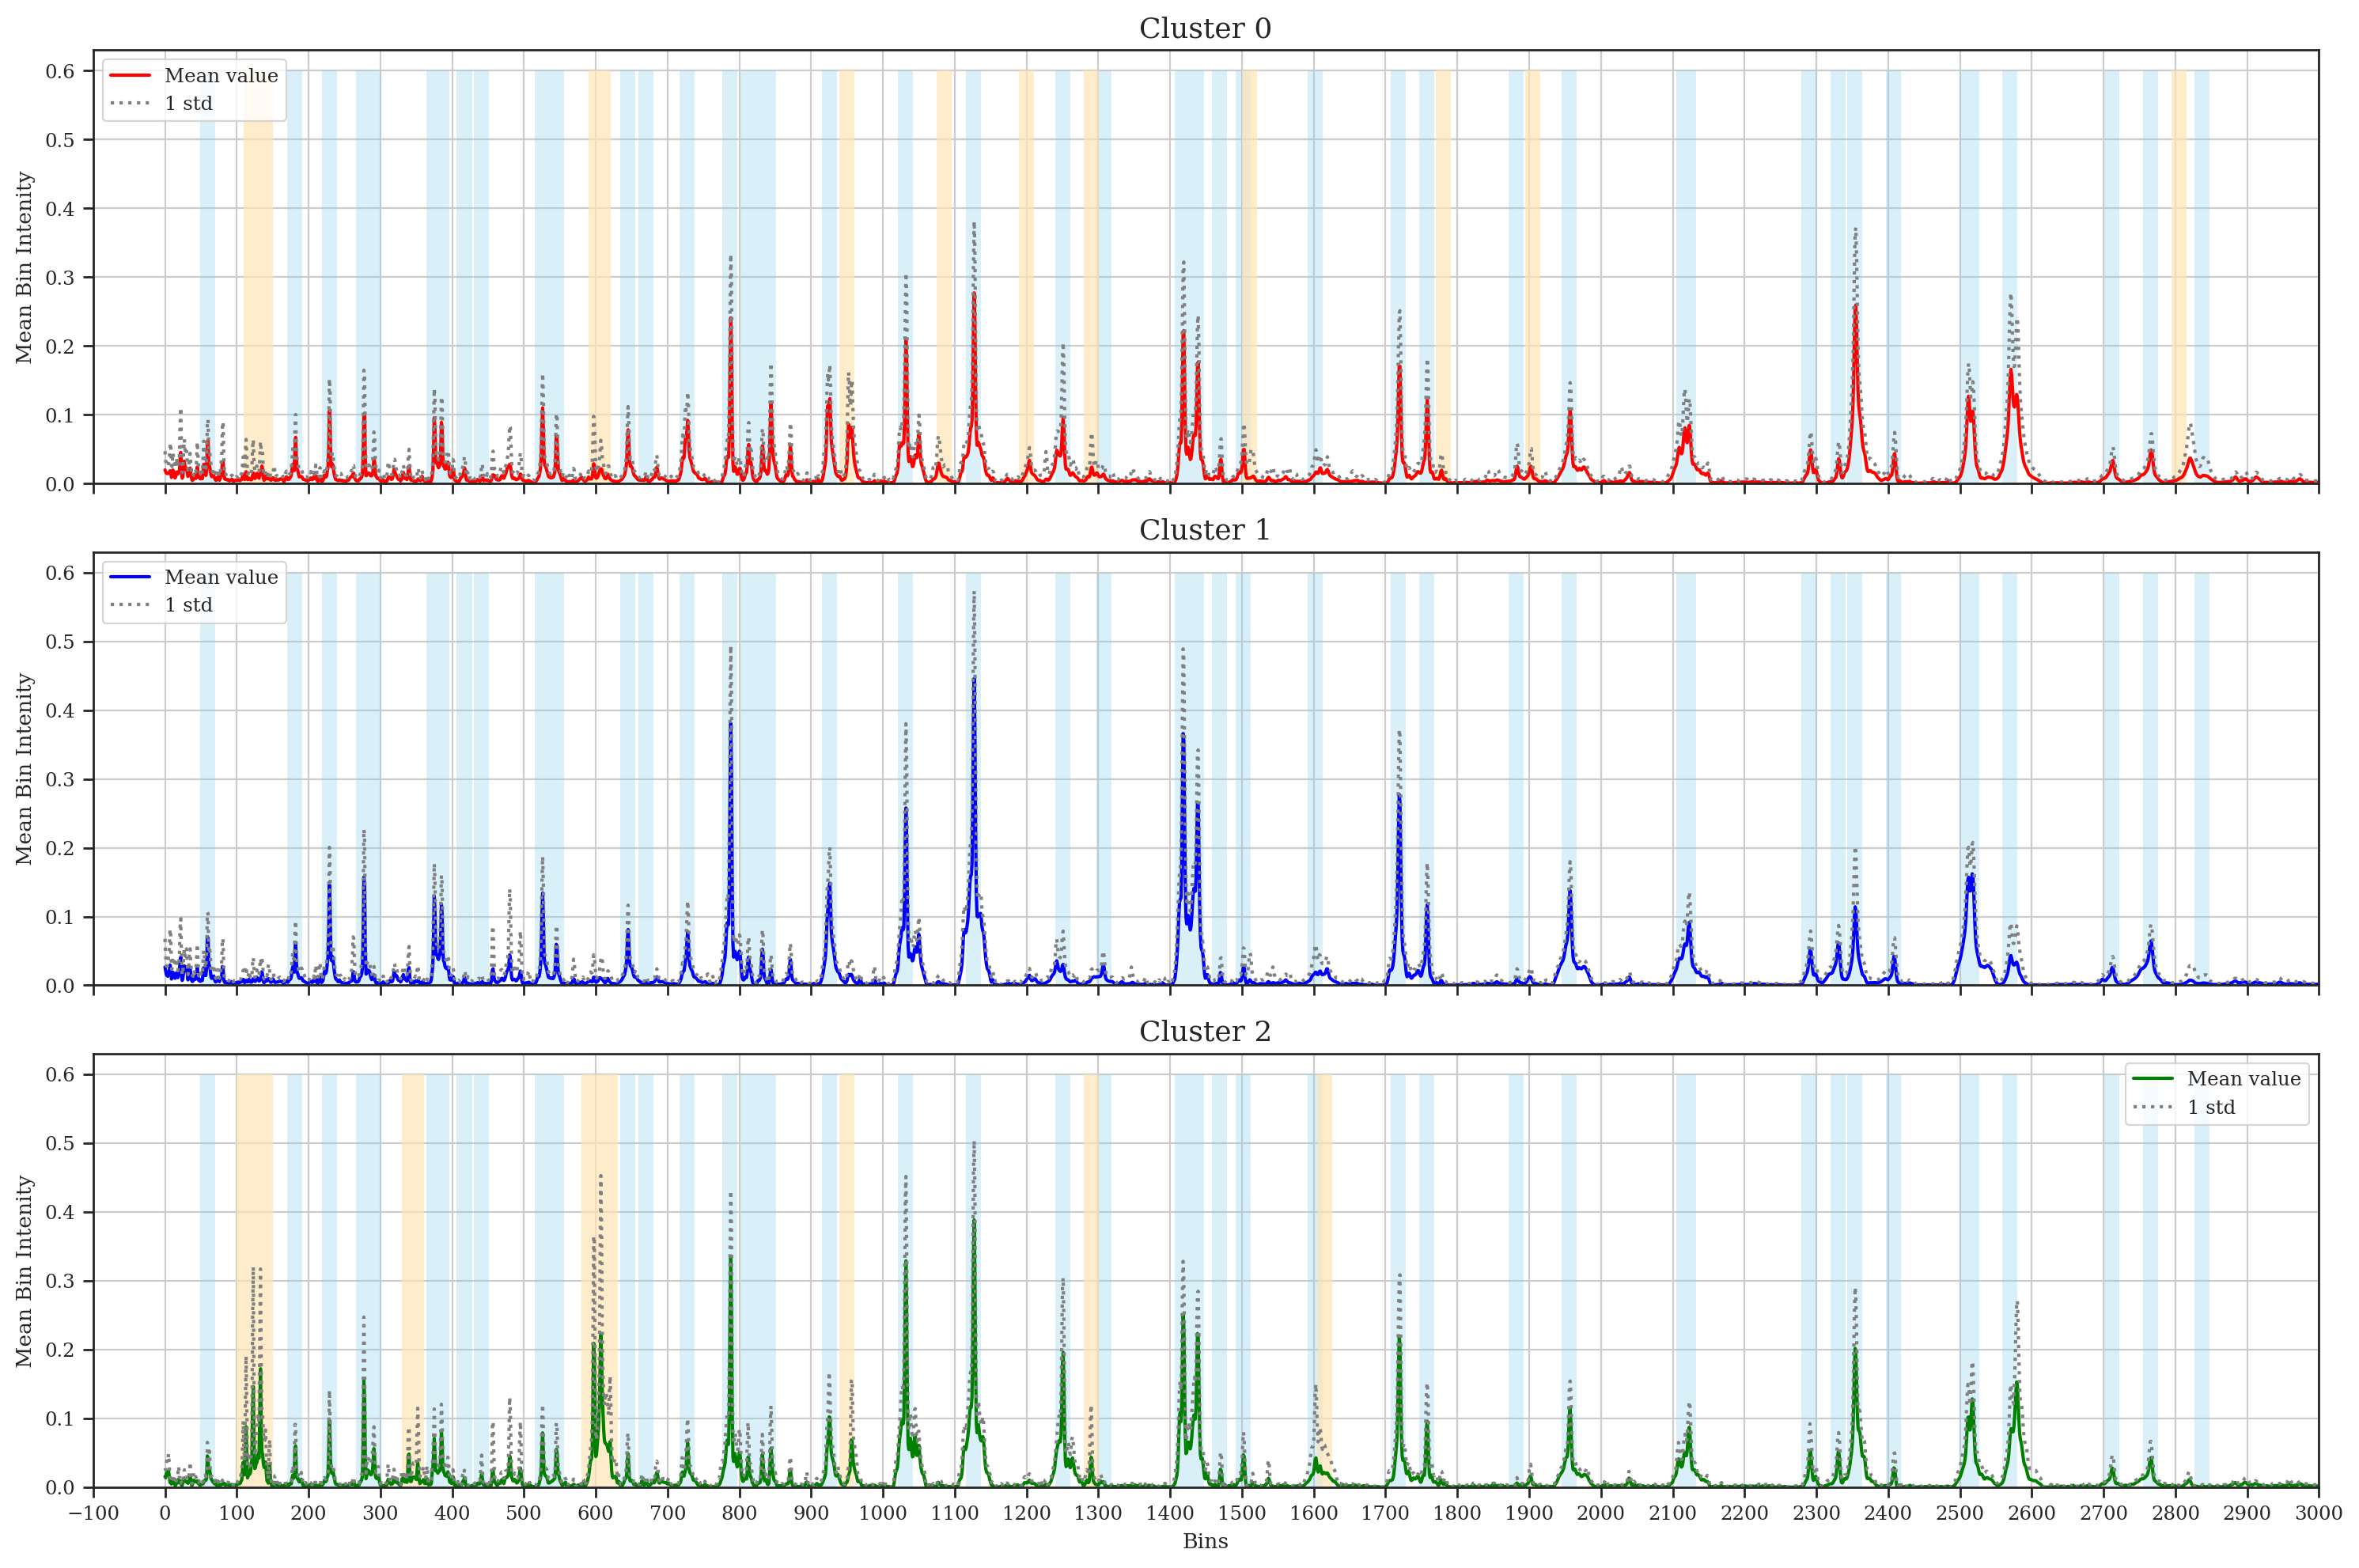

In [17]:
common_bins_dict = {0: [120, 130, 140, 600, 610, 950, 1085, 1200, 1290, 1510, 1780, 1905, 2805],
                    2: [110, 120, 130, 140, 340, 350, 590, 600, 610, 620, 950, 1290, 1615]
                }
plot_mean_maldi(SPR_results, common_bins_dict=common_bins_dict, fig_name='mean_MALDI_nonintersecting_assignment_ids_SPR')

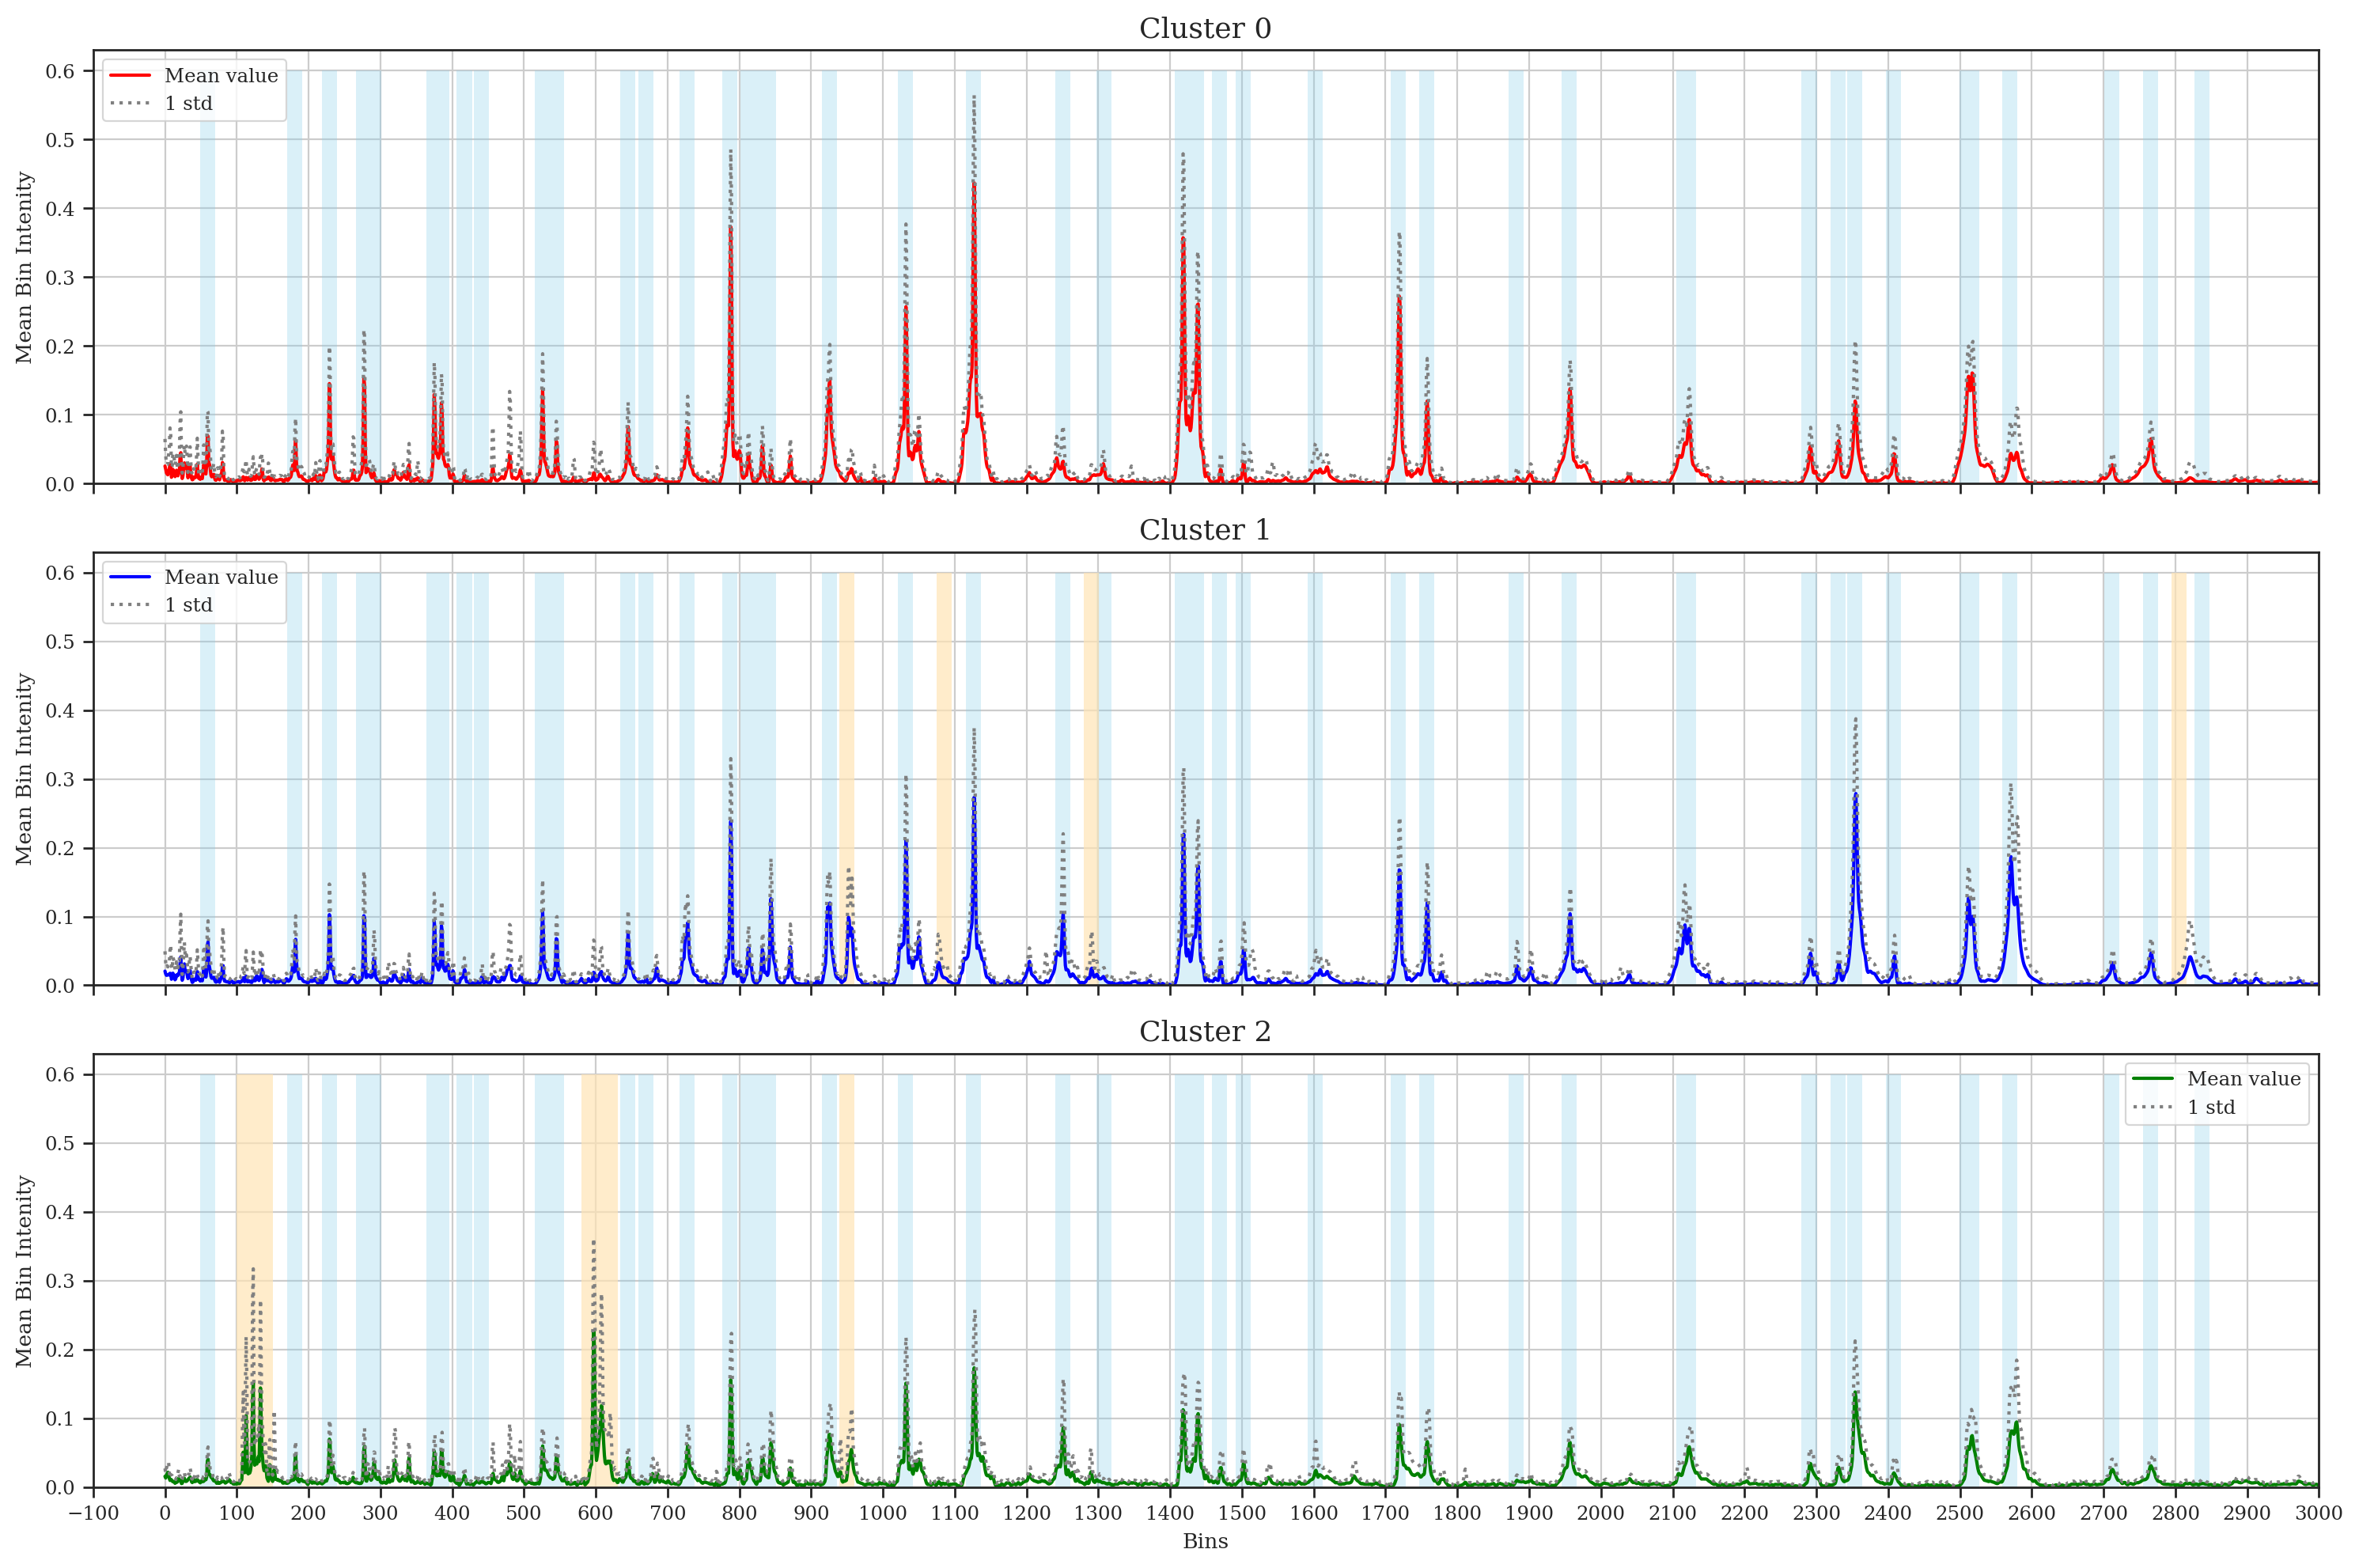

In [18]:
common_bins_dict = {1: [950, 1085, 1290, 2805], 
                    2: [110, 120, 130, 140, 590, 600, 610, 620, 950]}

plot_mean_maldi(noSPR_results, common_bins_dict=common_bins_dict, fig_name='mean_MALDI_nonintersecting_assignment_ids_noSPR')

In [19]:
common_bins_dict = {1: [950, 1075, 1290, 1905, 2805],
                    2: [110, 120, 130, 140, 340, 350, 590, 600, 610, 620, 1640, 1650]
                }

plot_mean_maldi(masked_results, common_bins_dict=common_bins_dict, fig_name='mean_MALDI_nonintersecting_assignment_ids_masked')

KeyboardInterrupt: 